<a href="https://colab.research.google.com/github/leeet1004835/colab/blob/main/0429.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

分類模型

「梯度遞減」(Gradient descent):
基本概念是先隨機初始化一組係數向量，以迭代更新該組係數向量，一直到J(w)收斂到局部最小值為止。

梯度遞減如何「有方向性地」更新係數向量:
依據損失函數J(w)關於係數向量w的偏微分來決定更新的方向性。
更新幅度則由一個大於零、稱為「學習速率」的常數α決定。

梯度遞減演算方法:
將目前的w0減去學習速率α乘上J(w)關於w0的偏微分、將目前的w1減去學習速率α乘上J(w)
關於w1的偏微分。

J(w)關於w的偏微分就是演算方法中所謂的「梯度」(Gradient):
在迭代過程中w更新的方向性取決於梯度正負號，如果梯度為正，w會向左更新(減小)；如果梯度為負，w會向右更新(增大)。

In [1]:
class GradientDescent:
    """
    This class defines the vanilla gradient descent algorithm for linear regression.
    Args:
        fit_intercept (bool): Whether to add intercept for this model.
    """
    def __init__(self, fit_intercept=True):
        self._fit_intercept = fit_intercept
    def find_gradient(self):
        """
        This function returns the gradient given certain model weights.
        """
        y_hat = np.dot(self._X_train, self._w)
        gradient = (2/self._m) * np.dot(self._X_train.T, y_hat - self._y_train)
        return gradient
    def mean_squared_error(self):
        """
        This function returns the mean squared error given certain model weights.
        """
        y_hat = np.dot(self._X_train, self._w)
        mse = ((y_hat - self._y_train).T.dot(y_hat - self._y_train)) / self._m
        return mse
    def fit(self, X_train, y_train, epochs=10000, learning_rate=0.001):
         """
         This function uses vanilla gradient descent to solve for weights of this model.
         Args:
             X_train (ndarray): 2d-array for feature matrix of training data.
             y_train (ndarray): 1d-array for target vector of training data.
             epochs (int): The number of iterations to update the model weights.
             learning_rate (float): The learning rate of gradient descent.
         """
         self._X_train = X_train.copy()
         self._y_train = y_train.copy()
         self._m = self._X_train.shape[0]
         if self._fit_intercept:
             X0 = np.ones((self._m, 1), dtype=float)
             self._X_train = np.concatenate([X0, self._X_train], axis=1)
         n = self._X_train.shape[1]
         self._w = np.random.rand(n)
         n_prints = 10
         print_iter = epochs // n_prints
         w_history = dict()
         for i in range(epochs):
             current_w = self._w.copy()
             w_history[i] = current_w
             mse = self.mean_squared_error()
             gradient = self.find_gradient()
             if i % print_iter == 0:
                 print("epoch: {:6} - loss: {:.6f}".format(i, mse))
             self._w -= learning_rate*gradient
         w_ravel = self._w.copy().ravel()
         self.intercept_ = w_ravel[0]
         self.coef_ = w_ravel[1:]
         self._w_history = w_history
         return self
    def predict(self, X_test):
        """
        This function returns predicted values with weights of this model.
        Args:
            X_test (ndarray): 2d-array for feature matrix of test data.
        """
        self._X_test = X_test
        m = self._X_test.shape[0]
        if self._fit_intercept:
            X0 = np.ones((m, 1), dtype=float)
            self._X_test = np.concatenate([X0, self._X_test], axis=1)
        y_pred = np.dot(self._X_test, self._w)
        return y_pred

In [2]:
import numpy as np

X0 = np.ones((10, 1))
X1 = np.arange(1, 11).reshape(-1, 1)
w = np.array([5, 6])
X_train = np.concatenate([X0, X1], axis=1)
y_train = np.dot(X_train, w)
print(X_train)
print(y_train)

[[ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]
 [ 1.  4.]
 [ 1.  5.]
 [ 1.  6.]
 [ 1.  7.]
 [ 1.  8.]
 [ 1.  9.]
 [ 1. 10.]]
[11. 17. 23. 29. 35. 41. 47. 53. 59. 65.]


In [3]:
h = GradientDescent(fit_intercept=False)
h.fit(X_train, y_train, epochs=20000, learning_rate=0.001)

epoch:      0 - loss: 1654.261244
epoch:   2000 - loss: 0.645341
epoch:   4000 - loss: 0.120254
epoch:   6000 - loss: 0.022409
epoch:   8000 - loss: 0.004176
epoch:  10000 - loss: 0.000778
epoch:  12000 - loss: 0.000145
epoch:  14000 - loss: 0.000027
epoch:  16000 - loss: 0.000005
epoch:  18000 - loss: 0.000001


In [4]:
print(h.intercept_) # 截距項
print(h.coef_)      # 係數項

4.999096811708821
[6.00012973]


In [5]:
# 將自行定義的梯度遞減預測器類別應用在真實資料
import pandas as pd
from sklearn.model_selection import train_test_split

player_stats = pd.read_csv("https://raw.githubusercontent.com/yaojenkuo/ml-newbies/master/player_stats.csv")
X = player_stats['heightMeters'].values.reshape(-1, 1)
y = player_stats['weightKilograms'].values
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
h = GradientDescent()
h.fit(X_train, y_train, epochs=300000, learning_rate=0.01) # 跑30萬次，學習率(步長)0.01

epoch:      0 - loss: 9305.836465
epoch:  30000 - loss: 53.010576
epoch:  60000 - loss: 49.518406
epoch:  90000 - loss: 48.904808
epoch: 120000 - loss: 48.796995
epoch: 150000 - loss: 48.778052
epoch: 180000 - loss: 48.774723
epoch: 210000 - loss: 48.774138
epoch: 240000 - loss: 48.774036
epoch: 270000 - loss: 48.774017


In [7]:
print(h.intercept_) # 截距項
print(h.coef_)      # 係數項

-95.12933762448057
[97.24446731]


In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.intercept_) # 截距項
print(lr.coef_)      # 係數項

-95.14864145823769
[97.25416437]


搭配兩種技法來增加效率:

1.特徵矩陣的標準化。
2.進階的梯度遞減演算方法。

In [9]:
# 以其中的 'GrLivArea' 作為特徵矩陣來預測目標向量 'SalePrice'
train = pd.read_csv("https://raw.githubusercontent.com/datainpoint/classroom-ml-from-scratch/main/data/house-prices/train.csv")
X = train['GrLivArea'].values.reshape(-1, 1)
y = train['SalePrice'].values
print(X.max())
print(y.max())
print(X.min())
print(y.min())

5642
755000
334
34900


In [10]:
# 自定義一個AdaGrad類別繼承GradientDescent類別並改寫其fit()方法
class AdaGrad(GradientDescent):
    def fit(self, X_train, y_train, epochs=10000, learning_rate=0.01, epsilon=1e-06):
        self._X_train = X_train.copy()
        self._y_train = y_train.copy()
        self._m = self._X_train.shape[0]
        if self._fit_intercept:
            X0 = np.ones((self._m, 1), dtype=float)
            self._X_train = np.concatenate([X0, self._X_train], axis=1)
        n = self._X_train.shape[1]
        self._w = np.random.rand(n)
        # 初始化 ssg
        ssg = np.zeros(n, dtype=float)
        n_prints = 10
        print_iter = epochs // n_prints
        w_history = dict()
        for i in range(epochs):
            current_w = self._w.copy()
            w_history[i] = current_w
            mse = self.mean_squared_error()
            gradient = self.find_gradient()
            ssg += gradient**2
            ada_grad = gradient / (epsilon + ssg**0.5)
            if i % print_iter == 0:
                print("epoch: {:6} - loss: {:.6f}".format(i, mse))
            # 以 adaptive gradient 更新 w
            self._w -= learning_rate*ada_grad
        w_ravel = self._w.copy().ravel()
        self.intercept_ = w_ravel[0]
        self.coef_ = w_ravel[1:]

In [11]:
adaptive_gradient = AdaGrad()

In [12]:
train = pd.read_csv("https://raw.githubusercontent.com/datainpoint/classroom-ml-from-scratch/main/data/house-prices/train.csv")
X = train['GrLivArea'].values.reshape(-1, 1)
y = train['SalePrice'].values
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.33, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.intercept_)
print(lr.coef_)

30774.037736162078
[98.50395317]


In [21]:
vanilla_gd = GradientDescent()
vanilla_gd.fit(X_train, y_train, epochs=2000, learning_rate=0.01)

epoch:      0 - loss: 22.081401
epoch:    200 - loss: 0.138794
epoch:    400 - loss: 0.137375
epoch:    600 - loss: 0.137102
epoch:    800 - loss: 0.137050
epoch:   1000 - loss: 0.137040
epoch:   1200 - loss: 0.137038
epoch:   1400 - loss: 0.137037
epoch:   1600 - loss: 0.137037
epoch:   1800 - loss: 0.137037


In [22]:
print(vanilla_gd.intercept_) # 截距項
print(vanilla_gd.coef_)      # 係數項

0.3203274494444908
[-0.14537813  0.12968483]


In [15]:
adaptive_gd = AdaGrad()
adaptive_gd.fit(X_train, y_train, epochs=500000, learning_rate=100)

epoch:      0 - loss: 38043447572.273735
epoch:  50000 - loss: 3146394287.008214
epoch: 100000 - loss: 3141881640.046235
epoch: 150000 - loss: 3141504033.241901
epoch: 200000 - loss: 3141471599.465272
epoch: 250000 - loss: 3141468807.541415
epoch: 300000 - loss: 3141468567.165437
epoch: 350000 - loss: 3141468546.469478
epoch: 400000 - loss: 3141468544.687588
epoch: 450000 - loss: 3141468544.534171


In [16]:
print(adaptive_gd.intercept_) # 截距項
print(adaptive_gd.coef_)      # 係數項

30773.928982965885
[98.50401696]


In [17]:
print(np.log(0 + 1e-6))

-13.815510557964274


In [18]:
# 自訂羅吉斯迴歸類別LogitReg
class LogitReg:
    """
    This class defines the vanilla descent algorithm for logistic regression.
    Args:
        fit_intercept (bool): Whether to add intercept for this model.
    """
    def __init__(self, fit_intercept=True):
        self._fit_intercept = fit_intercept
    def sigmoid(self, X):
        """
        This function returns the Sigmoid output as a probability given certain model weights.
        """
        X_w = np.dot(X, self._w)
        p_hat = 1 / (1 + np.exp(-X_w))
        return p_hat
    def find_gradient(self):
        """
        This function returns the gradient given certain model weights.
        """
        m = self._m
        p_hat = self.sigmoid(self._X_train)
        X_train_T = np.transpose(self._X_train)
        gradient = (1/m) * np.dot(X_train_T, p_hat - self._y_train)
        return gradient
    def cross_entropy(self, epsilon=1e-06):
        """
        This function returns the cross entropy given certain model weights.
        """
        m = self._m
        p_hat = self.sigmoid(self._X_train)
        cost_y1 = -np.dot(self._y_train, np.log(p_hat + epsilon))
        cost_y0 = -np.dot(1 - self._y_train, np.log(1 - p_hat + epsilon))
        cross_entropy = (cost_y1 + cost_y0) / m
        return cross_entropy
    def fit(self, X_train, y_train, epochs=10000, learning_rate=0.001):
        """
        This function uses vanilla gradient descent to solve for weights of this model.
        Args:
            X_train (ndarray): 2d-array for feature matrix of training data.
            y_train (ndarray): 1d-array for target vector of training data.
            epochs (int): The number of iterations to update the model weights.
            learning_rate (float): The learning rate of gradient descent.
        """
        self._X_train = X_train.copy()
        self._y_train = y_train.copy()
        m = self._X_train.shape[0]
        self._m = m
        if self._fit_intercept:
            X0 = np.ones((self._m, 1), dtype=float)
            self._X_train = np.concatenate([X0, self._X_train], axis=1)
        n = self._X_train.shape[1]
        self._w = np.random.rand(n)
        n_prints = 10
        print_iter = epochs // n_prints
        for i in range(epochs):
            cross_entropy = self.cross_entropy()
            gradient = self.find_gradient()
            if i % print_iter == 0:
                print("epoch: {:6} - loss: {:.6f}".format(i, cross_entropy))
            self._w -= learning_rate*gradient
        w_ravel = self._w.ravel().copy()
        self.intercept_ = w_ravel[0]
        self.coef_ = w_ravel[1:].reshape(1, -1)
    def predict_proba(self, X_test):
        """
        This function returns predicted probability with weights of this model.
        Args:
            X_test (ndarray): 2d-array for feature matrix of test data.
        """
        m = X_test.shape[0]
        if self._fit_intercept:
            X0 = np.ones((m, 1), dtype=float)
            self._X_test = np.concatenate([X0, X_test], axis=1)
        p_hat_1 = self.sigmoid(self._X_test).reshape(-1, 1)
        p_hat_0 = 1 - p_hat_1
        proba = np.concatenate([p_hat_0, p_hat_1], axis=1)
        return proba
    def predict(self, X_test):
        """
        This function returns predicted label with weights of this model.
        Args:
            X_test (ndarray): 2d-array for feature matrix of test data.
        """
        proba = self.predict_proba(X_test)
        y_pred = np.argmax(proba, axis=1)
        return y_pred

In [19]:
X = player_stats[['apg', 'rpg']].values
pos = player_stats['pos'].values
position_dictionary = {
    0: "G",
    1: "F"
}
y = np.array([0 if p[0] == 'G' else 1 for p in pos])
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.33, random_state=42)
my_logistic_regression = LogitReg()
my_logistic_regression.fit(X_train, y_train, 100000, 0.01)

epoch:      0 - loss: 1.889256
epoch:  10000 - loss: 0.313565
epoch:  20000 - loss: 0.311947
epoch:  30000 - loss: 0.311872
epoch:  40000 - loss: 0.311868
epoch:  50000 - loss: 0.311868
epoch:  60000 - loss: 0.311868
epoch:  70000 - loss: 0.311868
epoch:  80000 - loss: 0.311868
epoch:  90000 - loss: 0.311868


In [20]:
print(my_logistic_regression.intercept_) # 截距項
print(my_logistic_regression.coef_)      # 係數項

-2.071218674321561
[[-2.06557266  1.71544419]]


集成模型

k 最近鄰(k-Nearest Neighbors, KNN)是一種基於資料之間的相似度來決定是否為同一類別的演算方法。

k 最近鄰會根據預測資料點周遭的 k 個最相似訓練資料點決定分類結果，k 可以由使用者自行決定。



決策樹(Decision tree)是一種利用外型像樹一樣的圖形決策模型，具有快速、可解釋性高的優點。

決策樹需要從資料中尋找合適的「特徵」與「切點」來進行樹的分支，多次分支後企圖讓資料有高差異性的分類。

建立一個決策樹模型必須要考量三個要素：
1.要使用資料中的哪個變數作為特徵。
2.要如何決定特徵的切點。
3.何時要停止分支。

使用演算法計算資訊增益(Information Gain)、熵(Entropy)、資訊增益率(Information Gain Ratio)或吉尼不純度(Gini Impurity)來決定前述三要素。

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

k_neighbors_clf = KNeighborsClassifier()
k_neighbors_clf.fit(X_train, y_train)
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train, y_train)
decision_tree_clf = DecisionTreeClassifier()
decision_tree_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [24]:
y_hat_knn = k_neighbors_clf.predict(X_valid)
y_hat_gaussian_nb = gaussian_nb.predict(X_valid)
y_hat_decision_tree = decision_tree_clf.predict(X_valid)
print(y_hat_knn)
print(y_hat_gaussian_nb)
print(y_hat_decision_tree)

[1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 1 1 1 1 0 1
 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 0 0
 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1
 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1
 1 1 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0]
[1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0
 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0
 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1
 0 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1
 1 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1]
[0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1
 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 0 0 0
 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1
 0 0 1 0 1 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1
 1 1 0 1 1 1 0 0 0 0 1 1

以隨機森林模型理解 Bagging

Bagging 指的是樣本重複抽樣，產生多個子資料集後依序建立多個模型，最後再將所有模型的結果彙整在一起。

隨機森林模型運用 Bagging 與決策樹，多個模型全都都是用決策樹來建模，故得名「森林」。

隨機森林模型在抽樣過程中，不只是對列數(Rows)進行抽樣，同時也會對欄數(Columns)抽樣，因此產生的子集資料，其實是對列跟欄抽樣後的結果。

面對資料中有共線性(Collinearity)跟類別不平衡(Class Imbalance)時採用隨機森林模型，對列抽樣時，可以部份解決類別不平衡來影響預測的問題；對欄抽樣時，可以部份解決共線性來影響預測的問題。

正確分類:
真陰性(True negative,TN):y(valid)=0並且^y(valid)=0
真陽性(True positive,TP):y(valid)=1並且^y(valid)=1

錯誤分類:
偽陰性(False negative,FN):y(valid)=1並且^y(valid)=0
偽陽性(False positive,FP):y(valid)=0並且^y(valid)=1


混淆矩陣(Confusion matrix):以2×2矩陣表達正確、錯誤分類的情境。

真陰性(True negative,TN) 偽陽性(False positive,FP)
偽陰性(False negative,FN) 真陽性(True positive,TP)

使用 Scikit-Learn 定義好的 confusion_matrix 函數創造兩個目標向量之間正確分類、錯誤分類所組成的混淆矩陣。

準確率(Accuracy): 是類別預測任務最常用的評估指標。
Accuracy=(TN+TP)/(TN+TP+FN+FP)

精確率(Precision):是分類器在所有預測為陽性的觀測值中，正確預測的觀測值數為多少。
Precision=(TP)/(TP+FP)

召回率(Recall):是分類器在所有陽性的觀測值中，正確預測的觀測值數為多少。
Recall=(TP)/(TP+FN)

採用精確率代表的要盡可能降低偽陽性，這表示的是偽陽性的成本高，意味著是誤判為陽性事件的成本高（例如誤診而進行高風險的手術）。

採用召回率代表的是要儘可能降低偽陰性，這表示的是偽陰性的成本高，意味著是誤判為陰性事件的成本高（例如誤診而導致超級傳播者沒有隔離而進入社區）。



In [35]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# 樸素分類器在精確率和召回率都得到了最低的評估值
precision = precision_score(y_true, y_hat, zero_division=0)
recall = recall_score(y_true, y_hat)
print(precision)
print(recall)

0.0
0.0


In [31]:
class ClfMetrics:
    """
    This class calculates some of the metrics of classifier including accuracy, precision, recall, f1 according to confusion matrix.
    Args:
        y_true (ndarray): 1d-array for true target vector.
        y_pred (ndarray): 1d-array for predicted target vector.
    """
    def __init__(self, y_true, y_pred):
        self._y_true = y_true
        self._y_pred = y_pred
    def confusion_matrix(self):
        """
        This function returns the confusion matrix given true/predicted target vectors.
        """
        n_unique = np.unique(self._y_true).size
        cm = np.zeros((n_unique, n_unique), dtype=int)
        for i in range(n_unique):
            for j in range(n_unique):
                n_obs = np.sum(np.logical_and(self._y_true == i, self._y_pred == j))
                cm[i, j] = n_obs
        self._tn = cm[0, 0]
        self._tp = cm[1, 1]
        self._fn = cm[1, 0]
        self._fp = cm[0, 1]
        return cm
    def accuracy_score(self):
        """
        This function returns the accuracy score given true/predicted target vectors.
        """
        cm = self.confusion_matrix()
        accuracy = (self._tn + self._tp) / np.sum(cm)
        return accuracy
    def precision_score(self):
        """
        This function returns the precision score given true/predicted target vectors.
        """
        precision = self._tp / (self._tp + self._fp)
        return precision
    def recall_score(self):
        """
        This function returns the recall score given true/predicted target vectors.
        """
        recall = self._tp / (self._tp + self._fn)
        return recall
    def f1_score(self, beta=1):
        """
        This function returns the f1 score given true/predicted target vectors.
        Args:
            beta (int, float): Can be used to generalize from f1 score to f score.
        """
        precision = self.precision_score()
        recall = self.recall_score()
        f1 = (1 + beta**2)*precision*recall / ((beta**2 * precision) + recall)
        return f1

In [36]:
from sklearn.linear_model import LogisticRegression
h = LogisticRegression()
h.fit(X_train, y_train)
y_hat = h.predict(X_valid)

In [39]:
# 混淆矩陣
clf_metrics = ClfMetrics(y_valid, y_hat)
clf_metrics.confusion_matrix()

array([[67, 10],
       [18, 71]])

In [40]:
# 準確率
clf_metrics.accuracy_score()

np.float64(0.8313253012048193)

In [41]:
# 精確率
clf_metrics.precision_score()

np.float64(0.8765432098765432)

In [42]:
# 召回率
clf_metrics.recall_score()

np.float64(0.797752808988764)

In [43]:
# F1-score
clf_metrics.f1_score()

np.float64(0.8352941176470587)

ARIMA(AutoRegressive Integrated Moving Average)是最常見的時間序列模型：

AutoRegressive指的是用xt1到xt−1來預測xt。

Integrated指的是「差分」，目的是使時間序列資料呈現穩態(Stationery)。

Moving Average用來描述AutoRegressive模型的殘差與xt的關係。

In [44]:
import yfinance as yf

dat = yf.Ticker("VT")
df = dat.history(period="12mo")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-04-29 00:00:00-04:00,113.738289,114.729702,113.689206,114.513756,2407600,0.0,0.0,0.0
2025-04-30 00:00:00-04:00,113.404535,114.818045,112.373857,114.454849,2252900,0.0,0.0,0.0
2025-05-01 00:00:00-04:00,115.505162,115.789828,114.719884,114.867119,1487600,0.0,0.0,0.0
2025-05-02 00:00:00-04:00,116.437691,117.036469,116.162836,116.869591,1592700,0.0,0.0,0.0
2025-05-05 00:00:00-04:00,116.575115,117.114992,116.398426,116.614380,1761900,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-04-22 00:00:00-04:00,149.860001,150.130005,149.660004,150.100006,1863900,0.0,0.0,0.0
2026-04-23 00:00:00-04:00,149.710007,150.149994,147.699997,149.149994,3382900,0.0,0.0,0.0
2026-04-24 00:00:00-04:00,149.720001,150.419998,149.279999,150.339996,4861300,0.0,0.0,0.0


In [47]:
import matplotlib.pyplot as plt

ts = df["Close"]
ts

,Close
Date,
2025-04-29 00:00:00-04:00,114.513756
2025-04-30 00:00:00-04:00,114.454849
2025-05-01 00:00:00-04:00,114.867119
2025-05-02 00:00:00-04:00,116.869591
2025-05-05 00:00:00-04:00,116.614380
...,...
2026-04-22 00:00:00-04:00,150.100006
2026-04-23 00:00:00-04:00,149.149994
2026-04-24 00:00:00-04:00,150.339996


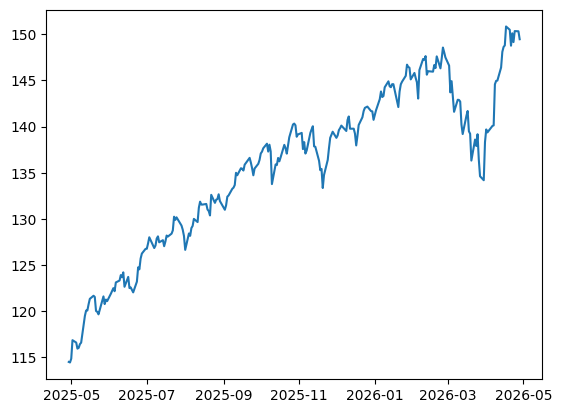

In [57]:
# 繪製原始的時間序列資料（未差分）
fig, ax = plt.subplots()
ax.plot(ts)
plt.show()

In [54]:
# Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

def adf_test_on_ts(ts) -> None:
    adf_test = adfuller(ts)
    p_value = adf_test[1]
    is_adf_test_passed = p_value < 0.05
    print(f"p-value of Augmented Dickey-Fuller Test: {p_value}")
    print(f"Is Augmented Dickey-Fuller Test passed: {is_adf_test_passed}")

adf_test_on_ts(ts)

p-value of Augmented Dickey-Fuller Test: 0.38256039658131386
Is Augmented Dickey-Fuller Test passed: False


In [55]:
# 一次差分之後再做 Augmented Dickey-Fuller Test
from statsmodels.graphics.tsaplots import plot_acf

close_diff = ts.diff().dropna()
print(close_diff)
adf_test_on_ts(close_diff) # suggests d = 1

Date
2025-04-30 00:00:00-04:00   -0.058907
2025-05-01 00:00:00-04:00    0.412270
2025-05-02 00:00:00-04:00    2.002472
2025-05-05 00:00:00-04:00   -0.255211
2025-05-06 00:00:00-04:00   -0.657677
                               ...   
2026-04-22 00:00:00-04:00    1.340012
2026-04-23 00:00:00-04:00   -0.950012
2026-04-24 00:00:00-04:00    1.190002
2026-04-27 00:00:00-04:00   -0.019989
2026-04-28 00:00:00-04:00   -0.860001
Name: Close, Length: 250, dtype: float64
p-value of Augmented Dickey-Fuller Test: 1.1577796124681254e-29
Is Augmented Dickey-Fuller Test passed: True


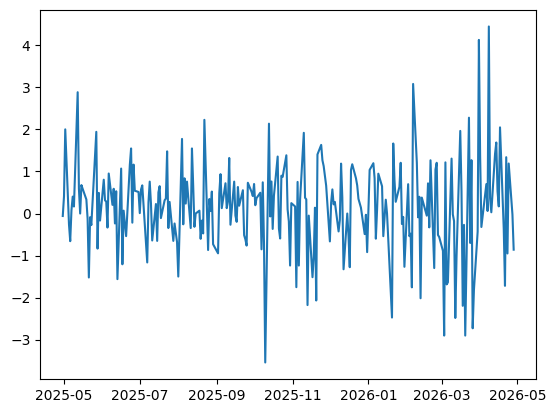

In [56]:
# 繪製差分一次的時間序列資料
fig, ax = plt.subplots()
ax.plot(close_diff)
plt.show()

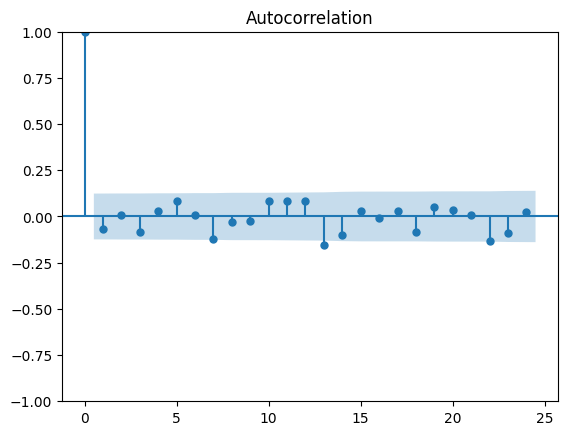

In [58]:
# 透過 Autocorrelation Function(ACF)決定 p 作為 ARIMA 模型的參數
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(close_diff)
plt.show() # suggests p = 1

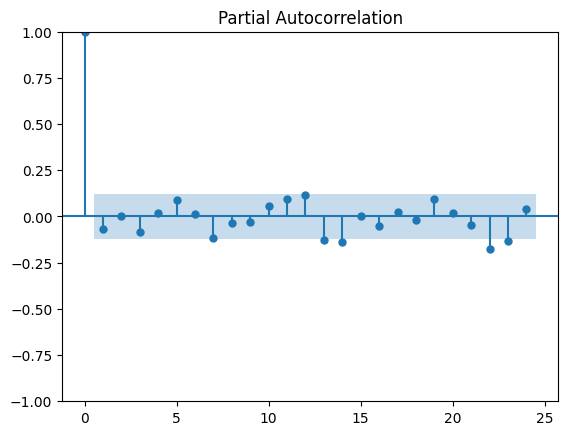

In [60]:
# 透過 Partial Autocorrelation Function(PACF)決定 q 作為 ARIMA 模型的參數
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(close_diff) # suggests q = 1
plt.show()

In [61]:
# 建立訓練與驗證資料
train_size = int(len(close_diff) * 0.8)
y_train, y_valid = close_diff.iloc[:train_size], close_diff.iloc[train_size:]

In [62]:
# 建立 ARIMA 模型訓練並預測
from statsmodels.tsa.arima.model import ARIMA

p, d, q = 1, 1, 1
steps_to_be_predicted = y_valid.size
model = ARIMA(y_train.values, order=(p, d, q))
model_fit = model.fit()
forecast = model_fit.get_forecast(steps=steps_to_be_predicted)

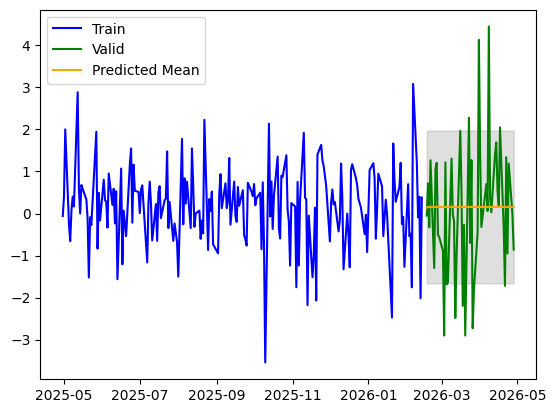

In [63]:
# 繪圖驗證
fig, ax = plt.subplots()
ax.plot(y_train.index, y_train.values, label="Train", color="Blue")
ax.plot(y_valid.index, y_valid.values, label="Valid", color="Green")
ax.plot(y_valid.index, forecast.predicted_mean, label="Predicted Mean", color="Orange")
ax.fill_between(y_valid.index, forecast.conf_int()[:, 0],
                forecast.conf_int()[:, 1],
                color="Grey", alpha=.25)
plt.legend()
plt.show()